<a href="https://sigmoidal.ai">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="300">
</a>

# YOLO em imagens térmicas aéreas

**Autor:** Carlos Melo — [sigmoidal.ai](https://sigmoidal.ai)

Adaptação de um YOLOv8s ao conjunto [POP](https://www.nature.com/articles/s41597-025-04600-0) (*Partially Occluded Person*): detecção de pessoas pequenas, vistas do nadir, em imagens térmicas de drone.

O notebook parte de um detector generalista treinado no COCO, inspeciona o domínio térmico, converte as anotações, treina com *transfer learning* e compara visualmente o comportamento antes e depois da especialização.

Artigo: [YOLO em imagens térmicas](https://sigmoidal.ai/yolo-imagens-termicas-adaptar-dominio/)


## Como usar

O notebook foi preparado para o Google Colab com GPU. Execute as células em ordem.

O arquivo `POP.zip` e os *checkpoints* ficam no Google Drive para sobreviver ao fim da sessão. As imagens usadas no treinamento são materializadas no disco local.

A variável `TRAIN_ACTION` controla o fluxo:

- `new` inicia um treinamento novo;
- `resume` retoma a partir de `last.pt`;
- `skip` abre os resultados de uma execução concluída.

Os resultados exibidos neste arquivo correspondem a uma execução já realizada. Não é necessário retreinar para estudar o raciocínio. O peso final não acompanha o repositório: para reproduzir a inferência, execute o treinamento (`TRAIN_ACTION = "new"`) ou use `skip` depois de apontar `BEST_CHECKPOINT` para um `best.pt` que você já tenha gerado.


In [1]:
%pip install ultralytics==8.4.115


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/45.5 kB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.8 MB/s eta 0:00:00


## 1. Preparar o ambiente

Fixamos a versão do Ultralytics e registramos o ambiente. Isso reduz diferenças entre execuções.


In [2]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import shutil
import urllib.request
import zipfile
from collections import defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import ultralytics
from google.colab import drive
from torchvision.ops import nms
from ultralytics import YOLO

assert torch.cuda.is_available(), "Selecione uma GPU no ambiente do Colab."

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Ultralytics:", ultralytics.__version__)
print("GPU:", torch.cuda.get_device_name(0))


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Python: 3.12.13
PyTorch: 2.11.0+cu128
Ultralytics: 8.4.115
GPU: NVIDIA A100-SXM4-40GB


## 2. Organizar a persistência

As imagens usadas repetidamente durante o treinamento ficam no armazenamento local. O Drive guarda o arquivo original, os *checkpoints* e os pesos finais.


In [3]:
drive.mount("/content/drive")

DRIVE_PROJECT = Path("/content/drive/MyDrive/thermal-sar-pop-detection")
DRIVE_DATA = DRIVE_PROJECT / "data"
DRIVE_ARCHIVES = DRIVE_DATA / "archives"
EXPERIMENTS_DIR = DRIVE_PROJECT / "experiments"
MODELS_DIR = DRIVE_PROJECT / "models"

LOCAL_ROOT = Path("/content/pop_work")
LOCAL_ZIP = LOCAL_ROOT / "POP.zip"
EXTRACT_DIR = LOCAL_ROOT / "extracted"
YOLO_ROOT = LOCAL_ROOT / "pop_yolo"

DRIVE_POP_ZIP = DRIVE_ARCHIVES / "POP.zip"

for directory in (DRIVE_ARCHIVES, EXPERIMENTS_DIR, MODELS_DIR, LOCAL_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

print("Projeto:", DRIVE_PROJECT)


Mounted at /content/drive
Projeto: /content/drive/MyDrive/thermal-sar-pop-detection


## 3. Obter e verificar o POP

Na primeira execução, o arquivo é baixado do repositório oficial. Uma cópia permanece no Drive. Antes da extração, conferimos a assinatura SHA-256.


In [4]:
POP_URL = "https://osf.io/download/gm8u2/"
POP_SHA256 = "14e7c4ddffe6555de1da9033217a7d95981fa1bc63f9cd6a514c348e593741cf"

archive_was_cached = DRIVE_POP_ZIP.is_file()

if archive_was_cached:
    print("Copiando POP.zip do Drive para o SSD local.")
    shutil.copy2(DRIVE_POP_ZIP, LOCAL_ZIP)
else:
    print("Baixando POP.zip do repositório oficial.")
    urllib.request.urlretrieve(POP_URL, LOCAL_ZIP)

with LOCAL_ZIP.open("rb") as file:
    digest = hashlib.file_digest(file, "sha256").hexdigest()

assert digest == POP_SHA256, f"SHA-256 inesperado: {digest}"

if not archive_was_cached:
    shutil.copy2(LOCAL_ZIP, DRIVE_POP_ZIP)

print("Integridade do arquivo confirmada.")


Baixando POP.zip do repositório oficial.
Integridade do arquivo confirmada.


In [5]:
if not EXTRACT_DIR.exists():
    print("Extraindo o dataset.")
    EXTRACT_DIR.mkdir(parents=True)
    with zipfile.ZipFile(LOCAL_ZIP) as archive:
        archive.extractall(EXTRACT_DIR)

roots = [
    path
    for path in EXTRACT_DIR.rglob("POP")
    if (path / "train/Annotations/train.json").is_file()
]

if not roots and (EXTRACT_DIR / "train/Annotations/train.json").is_file():
    roots = [EXTRACT_DIR]

assert len(roots) == 1, f"Raiz POP não encontrada de forma única: {roots}"

POP_ROOT = roots[0]
print("POP_ROOT:", POP_ROOT)


Extraindo o dataset.
POP_ROOT: /content/pop_work/extracted/POP


## 4. Entender a divisão dos dados

O POP separa treino, validação e teste por cena. Em dados de drone, frames próximos do mesmo voo podem ser quase idênticos. Manter cenas distintas em cada divisão produz uma avaliação mais honesta.


In [6]:
def load_coco(split):
    path = POP_ROOT / split / "Annotations" / f"{split}.json"
    return json.loads(path.read_text(encoding="utf8"))


summary_rows = []

for split in ("train", "val", "test"):
    coco = load_coco(split)
    summary_rows.append({
        "split": split,
        "images": len(coco["images"]),
        "boxes": len(coco["annotations"]),
    })

pd.DataFrame(summary_rows)


   split  images  boxes
0  train    5548  18425
1    val    2320   6546
2   test     900   1840


## 5. Fixar casos visuais

Selecionamos imagens do conjunto de teste **antes** do treinamento. Elas permanecem fixas e serão usadas para comparar modelos sem escolher exemplos depois de ver o resultado.


In [7]:
test_coco = load_coco("test")
test_names = sorted(image["file_name"] for image in test_coco["images"])

preferred = [
    "T1_0000_30.291.JPG",
    "T2_0000_50.15.JPG",
]

demo_names = [name for name in preferred if name in test_names]

for scene in ("T1", "T2", "T3"):
    scene_names = [name for name in test_names if name.startswith(scene)]
    for fraction in (0.25, 0.75):
        index = int(len(scene_names) * fraction)
        demo_names.append(scene_names[index])

DEMO_NAMES = list(dict.fromkeys(demo_names))

if len(DEMO_NAMES) < 6:
    step = max(1, len(test_names) // 6)
    DEMO_NAMES.extend(test_names[::step])

DEMO_NAMES = list(dict.fromkeys(DEMO_NAMES))[:6]
DEMO_IMAGES = [POP_ROOT / "test/JPEGImages" / name for name in DEMO_NAMES]

for path in DEMO_IMAGES:
    assert path.is_file(), path

DEMO_NAMES


['T1_0000_30.291.JPG',
 'T2_0000_50.15.JPG',
 'T1_0076_29.613.JPG',
 'T1_0229_50.226.JPG',
 'T2_0065_50.496.JPG',
 'T2_0194_47.334.JPG']


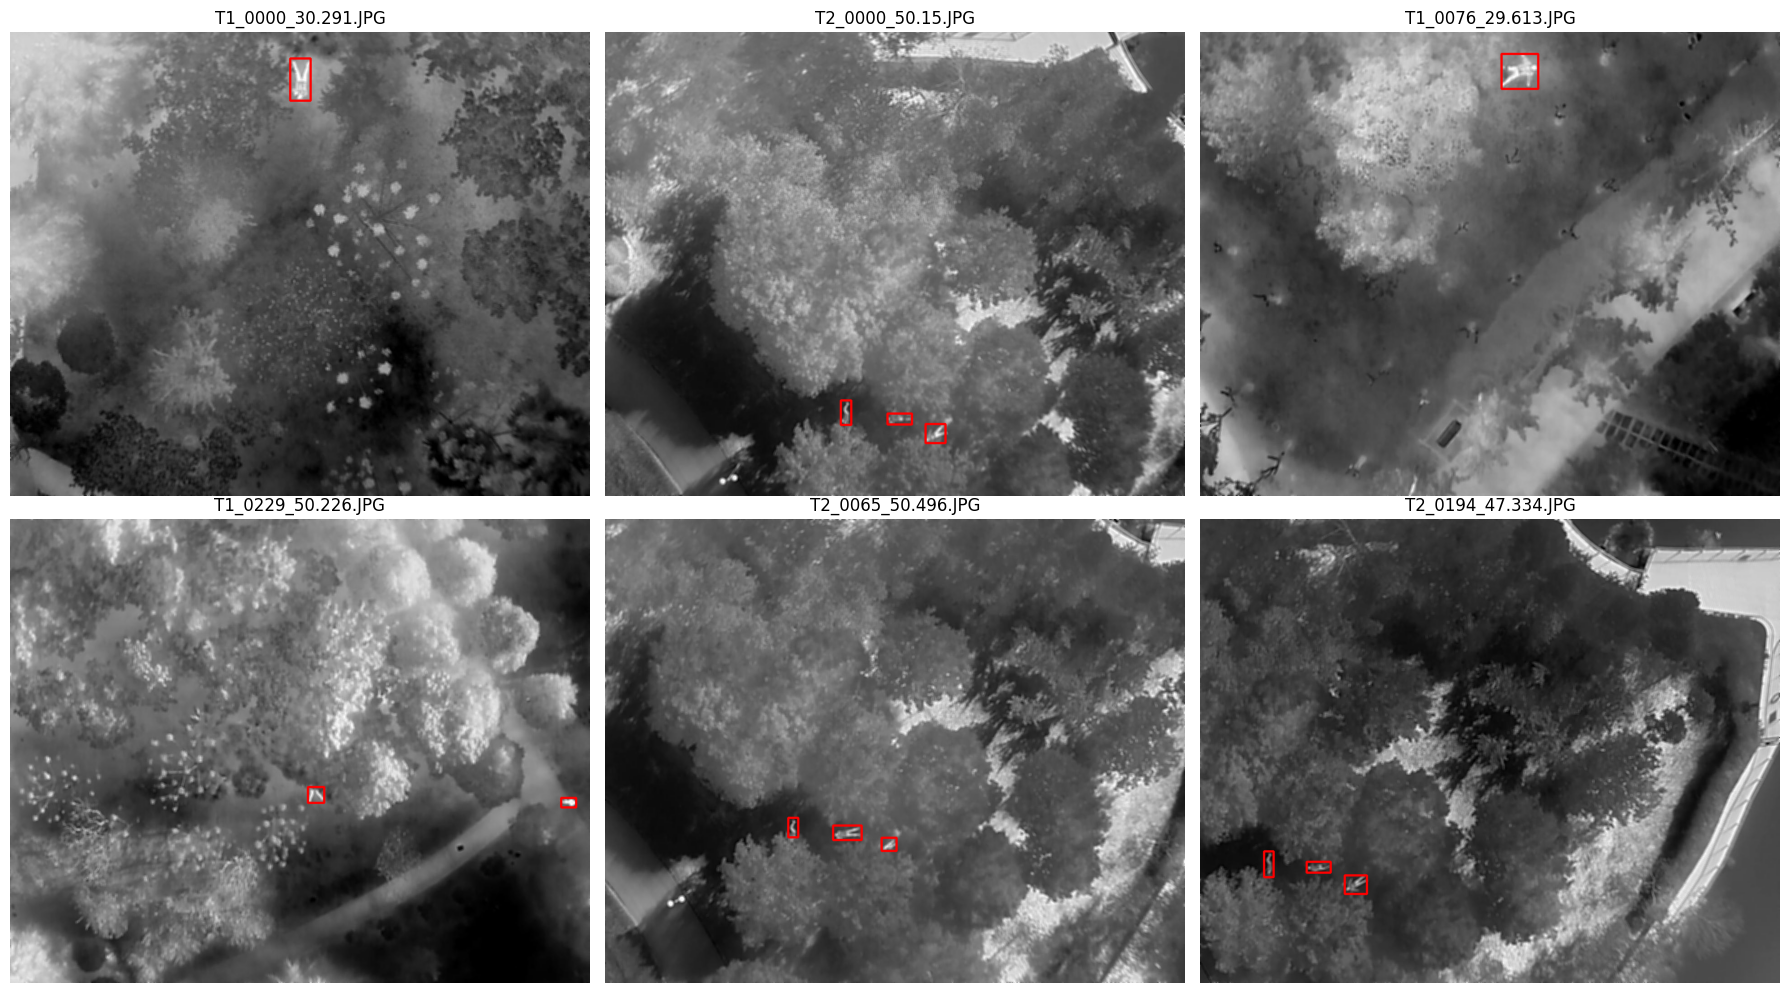

In [8]:
def ground_truth_boxes(image_name):
    images = {item["file_name"]: item for item in test_coco["images"]}
    image = images[image_name]
    return [
        annotation["bbox"]
        for annotation in test_coco["annotations"]
        if annotation["image_id"] == image["id"]
    ]


def image_with_ground_truth(path):
    image = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    for x, y, width, height in ground_truth_boxes(path.name):
        start = (int(x), int(y))
        end = (int(x + width), int(y + height))
        cv2.rectangle(image, start, end, (255, 0, 0), 3)
    return image


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for axis, path in zip(axes.flat, DEMO_IMAGES):
    axis.imshow(image_with_ground_truth(path))
    axis.set_title(path.name)
    axis.axis("off")

plt.tight_layout()
plt.show()


## 6. Confirmar o ponto de partida

Antes do domínio térmico, verificamos o detector em uma fotografia convencional. O objetivo é confirmar que o YOLOv8s reconhece `person` no tipo de imagem em que foi treinado.


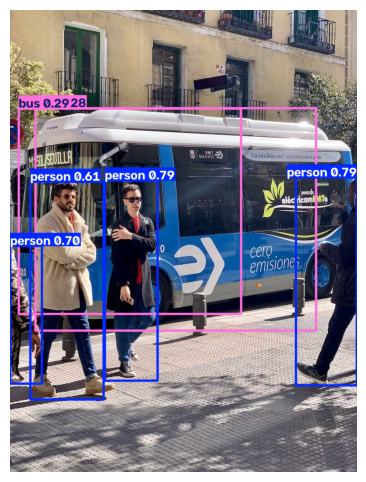

In [9]:
BUS_URL = "https://ultralytics.com/images/bus.jpg"
BUS_PATH = LOCAL_ROOT / "bus.jpg"

if not BUS_PATH.is_file():
    urllib.request.urlretrieve(BUS_URL, BUS_PATH)

coco_model = YOLO("yolov8s.pt")
bus_result = coco_model.predict(
    source=str(BUS_PATH),
    imgsz=1280,
    conf=0.25,
    verbose=False,
)[0]

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(bus_result.plot(), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


## 7. Testar o mesmo detector no domínio térmico

Mudam o sensor, a perspectiva, o fundo, a escala e a pose. A classe continua sendo `person`, mas a aparência é outra distribuição visual.


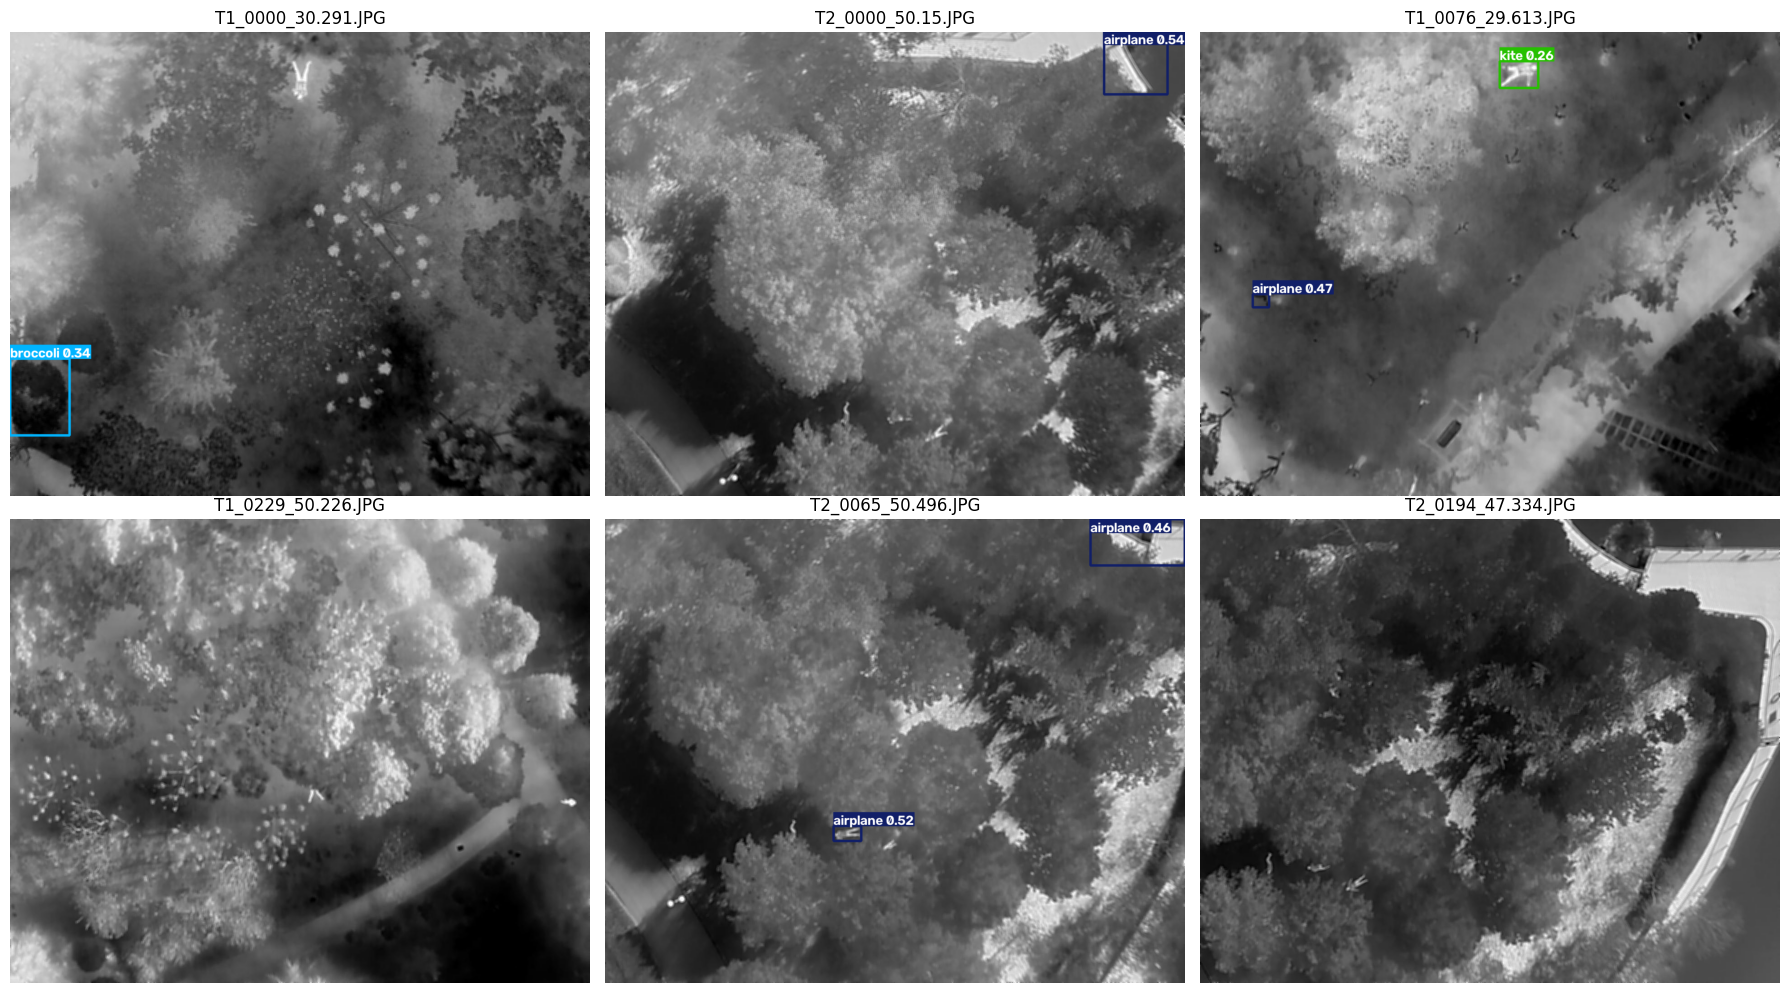

In [10]:
coco_demo_results = coco_model.predict(
    source=[str(path) for path in DEMO_IMAGES],
    imgsz=1280,
    conf=0.25,
    verbose=False,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for axis, result_item, path in zip(axes.flat, coco_demo_results, DEMO_IMAGES):
    axis.imshow(cv2.cvtColor(result_item.plot(), cv2.COLOR_BGR2RGB))
    axis.set_title(path.name)
    axis.axis("off")

plt.tight_layout()
plt.show()


In [11]:
for result_item, path in zip(coco_demo_results, DEMO_IMAGES):
    classes = [result_item.names[int(class_id)] for class_id in result_item.boxes.cls]
    print(path.name, classes if classes else "nenhuma detecção")


T1_0000_30.291.JPG ['broccoli']
T2_0000_50.15.JPG ['airplane']
T1_0076_29.613.JPG ['airplane', 'kite']
T1_0229_50.226.JPG nenhuma detecção
T2_0065_50.496.JPG ['airplane', 'airplane']
T2_0194_47.334.JPG nenhuma detecção


## 8. Verificar se uma geração mais recente resolve o problema

Repetimos os mesmos casos com YOLO11s treinado no COCO. A intenção não é comparar arquiteturas em detalhe, e sim observar se trocar a geração elimina, por si só, a mudança de domínio.


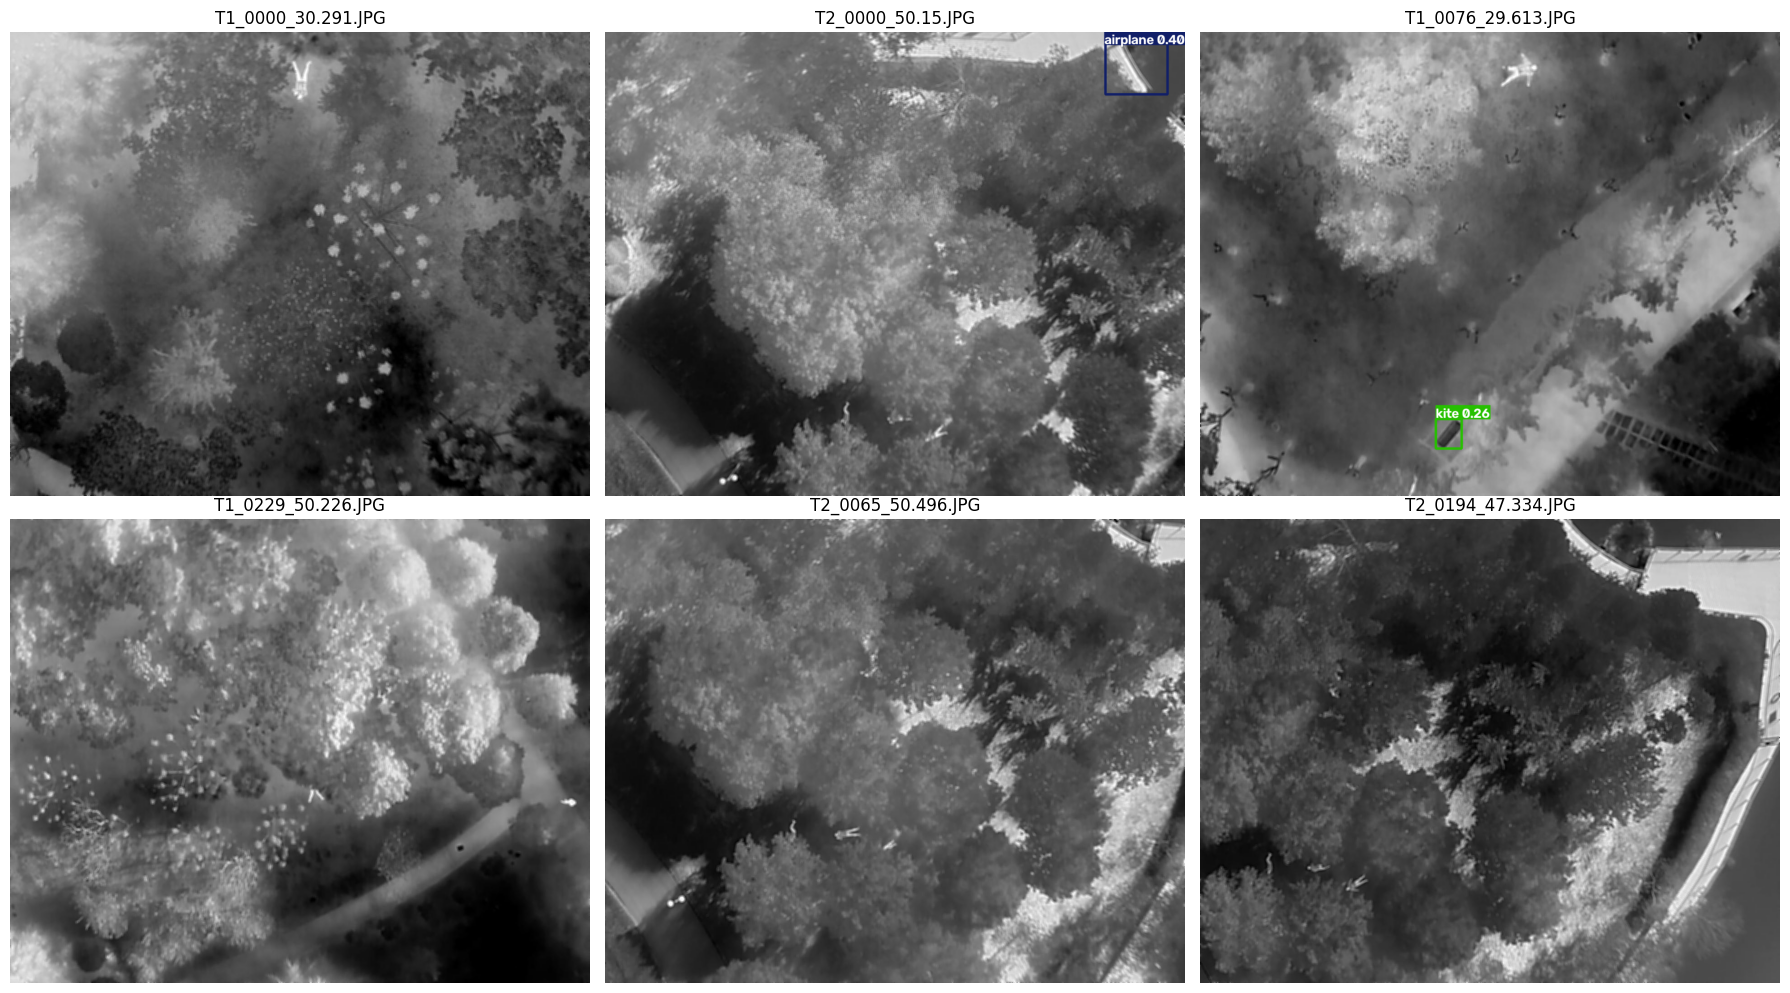

In [12]:
yolo11 = YOLO("yolo11s.pt")
yolo11_results = yolo11.predict(
    source=[str(path) for path in DEMO_IMAGES],
    imgsz=1280,
    conf=0.25,
    verbose=False,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for axis, result_item, path in zip(axes.flat, yolo11_results, DEMO_IMAGES):
    axis.imshow(cv2.cvtColor(result_item.plot(), cv2.COLOR_BGR2RGB))
    axis.set_title(path.name)
    axis.axis("off")

plt.tight_layout()
plt.show()


## 9. Definir a adaptação

O rótulo não mudou. O que mudou foi a forma como a pessoa aparece para o sensor.

Mantemos a arquitetura YOLOv8s e adaptamos seus pesos ao POP. Assim, o ganho observado vem da especialização do domínio, não de uma troca de família de modelo.


## 10. Converter as anotações

O POP fornece caixas no formato COCO JSON. O treinamento com Ultralytics espera *labels* YOLO. A conversão preserva classe, posição, escala e as três divisões originais.


In [13]:
YOLO_ROOT.mkdir(parents=True, exist_ok=True)


def materialize_image(source, destination):
    if destination.exists():
        return
    try:
        os.link(source, destination)
    except OSError:
        shutil.copy2(source, destination)


def yolo_line(annotation, image_width, image_height):
    x, y, width, height = annotation["bbox"]

    center_x = (x + width / 2) / image_width
    center_y = (y + height / 2) / image_height
    norm_width = width / image_width
    norm_height = height / image_height

    values = [center_x, center_y, norm_width, norm_height]
    assert all(0 <= value <= 1 for value in values)

    return "0 " + " ".join(f"{value:.6f}" for value in values)


def convert_split(split):
    coco = load_coco(split)

    categories = coco["categories"]
    assert len(categories) == 1, categories

    annotations_by_image = defaultdict(list)
    for annotation in coco["annotations"]:
        annotations_by_image[annotation["image_id"]].append(annotation)

    source_images = POP_ROOT / split / "JPEGImages"
    output_images = YOLO_ROOT / "images" / split
    output_labels = YOLO_ROOT / "labels" / split

    output_images.mkdir(parents=True, exist_ok=True)
    output_labels.mkdir(parents=True, exist_ok=True)

    box_count = 0

    for image in coco["images"]:
        source = source_images / image["file_name"]
        destination = output_images / image["file_name"]
        materialize_image(source, destination)

        lines_out = []
        for annotation in annotations_by_image[image["id"]]:
            lines_out.append(
                yolo_line(annotation, image["width"], image["height"])
            )
            box_count += 1

        label_path = output_labels / f"{Path(image['file_name']).stem}.txt"
        label_path.write_text("\n".join(lines_out) + "\n", encoding="utf8")

    return {"images": len(coco["images"]), "boxes": box_count}


conversion_summary = {
    split: convert_split(split)
    for split in ("train", "val", "test")
}

expected = {
    "train": {"images": 5548, "boxes": 18425},
    "val": {"images": 2320, "boxes": 6546},
    "test": {"images": 900, "boxes": 1840},
}

assert conversion_summary == expected, (conversion_summary, expected)

pd.DataFrame(conversion_summary).T


       images  boxes
train    5548  18425
val      2320   6546
test      900   1840


In [14]:
DATA_YAML = YOLO_ROOT / "pop.yaml"

DATA_YAML.write_text(
    f"""path: {YOLO_ROOT}
train: images/train
val: images/val
test: images/test

names:
  0: person
""",
    encoding="utf8",
)

print(DATA_YAML.read_text())


path: /content/pop_work/pop_yolo
train: images/train
val: images/val
test: images/test

names:
  0: person



## 11. Validar os *labels*

Antes de gastar tempo de GPU, conferimos quantidades e os limites das coordenadas normalizadas.


In [15]:
label_files = list((YOLO_ROOT / "labels").rglob("*.txt"))
checked_boxes = 0

for label_file in label_files:
    for line in label_file.read_text().splitlines():
        values = line.split()
        class_id = int(values[0])
        coordinates = [float(value) for value in values[1:]]

        assert class_id == 0
        assert len(coordinates) == 4
        assert all(0 <= value <= 1 for value in coordinates)

        checked_boxes += 1

assert checked_boxes == 26811

print("Labels verificados:", checked_boxes)


Labels verificados: 26811


## 12. Observar a escala dos alvos

Em imagens aéreas, uma pessoa pode ocupar uma fração muito pequena do quadro. O resumo e o histograma orientam a resolução de entrada.


In [16]:
box_rows = []

for split in ("train", "val", "test"):
    coco = load_coco(split)
    images = {image["id"]: image for image in coco["images"]}

    for annotation in coco["annotations"]:
        image = images[annotation["image_id"]]
        x, y, width, height = annotation["bbox"]

        box_rows.append({
            "split": split,
            "width_px": width,
            "height_px": height,
            "relative_area_pct": 100 * width * height / (image["width"] * image["height"]),
        })

boxes = pd.DataFrame(box_rows)

boxes[["width_px", "height_px", "relative_area_pct"]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9]
)


           width_px     height_px  relative_area_pct
count  26811.000000  26811.000000       26811.000000
mean      42.303085     49.242662           0.180428
std       19.772202     22.347541           0.155445
min        1.000000      1.000000           0.000076
25%       27.000000     32.000000           0.073700
50%       38.000000     44.000000           0.125351
75%       53.000000     61.000000           0.227280
90%       71.000000     86.000000           0.434494
max      116.000000    161.000000           1.031799


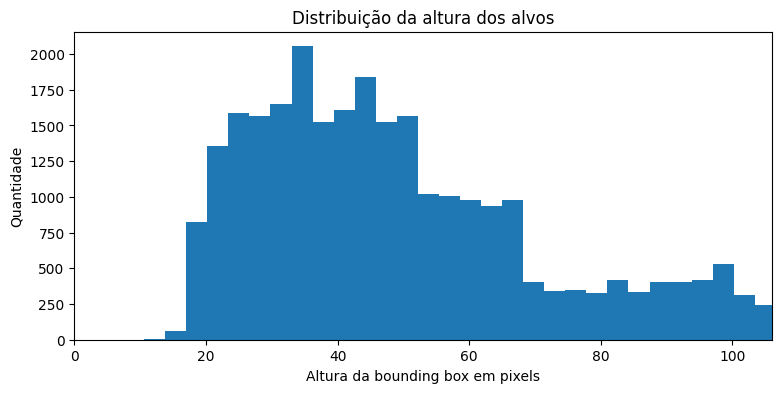

In [17]:
limit = boxes["height_px"].quantile(0.99)

plt.figure(figsize=(9, 4))
plt.hist(boxes["height_px"], bins=50)
plt.xlim(0, limit)
plt.xlabel("Altura da bounding box em pixels")
plt.ylabel("Quantidade")
plt.title("Distribuição da altura dos alvos")
plt.show()


## 13. Definir a estratégia de treinamento

Partimos de pesos treinados no COCO e fazemos *transfer learning* no POP.

A resolução de entrada é maior para preservar alvos pequenos. O número de épocas é um teto; o *early stopping* encerra a execução quando a validação permanece sem melhora. Em imagens térmicas, desativamos a variação de matiz e saturação.


In [18]:
EPOCHS = 100
PATIENCE = 20
IMGSZ = 1280
BATCH = 8

RUN_NAME = "yolov8s_pop_sar_live"
RUN_DIR = EXPERIMENTS_DIR / RUN_NAME

training_config = {
    "model": "yolov8s.pt",
    "epochs_max": EPOCHS,
    "patience": PATIENCE,
    "imgsz": IMGSZ,
    "batch": BATCH,
    "optimizer": "SGD",
    "lr0": 0.001,
    "seed": 0,
}

training_config


{'model': 'yolov8s.pt',
 'epochs_max': 100,
 'patience': 20,
 'imgsz': 1280,
 'batch': 8,
 'optimizer': 'SGD',
 'lr0': 0.001,
 'seed': 0}


## 14. Proteger a execução com *checkpoints*

O treinamento pode começar do zero, retomar uma execução interrompida ou apenas abrir resultados já concluídos.

O `last.pt` é o estado mais recente. O `best.pt` é o estado com melhor comportamento na validação. Os dois cumprem funções diferentes.


In [19]:
TRAIN_ACTION = "new"

assert TRAIN_ACTION in {"new", "resume", "skip"}

LAST_CHECKPOINT = RUN_DIR / "weights" / "last.pt"
BEST_CHECKPOINT = RUN_DIR / "weights" / "best.pt"
RESULTS_CSV = RUN_DIR / "results.csv"

print("Ação:", TRAIN_ACTION)
print("Run:", RUN_DIR)
print("last.pt encontrado:", LAST_CHECKPOINT.is_file())
print("best.pt encontrado:", BEST_CHECKPOINT.is_file())


Ação: new
Run: /content/drive/MyDrive/thermal-sar-pop-detection/experiments/yolov8s_pop_sar_live
last.pt encontrado: False
best.pt encontrado: False


In [20]:
if TRAIN_ACTION == "new":
    if RUN_DIR.exists() and any(RUN_DIR.iterdir()):
        raise RuntimeError(
            "Esta pasta já contém uma execução. "
            "Use resume, skip ou altere RUN_NAME."
        )

    model = YOLO("yolov8s.pt")

    train_results = model.train(
        data=str(DATA_YAML),
        epochs=EPOCHS,
        patience=PATIENCE,
        imgsz=IMGSZ,
        batch=BATCH,
        optimizer="SGD",
        lr0=0.001,
        device=0,
        workers=2,
        amp=True,
        pretrained=True,
        seed=0,
        deterministic=True,
        hsv_h=0.0,
        hsv_s=0.0,
        save=True,
        save_period=5,
        plots=True,
        project=str(EXPERIMENTS_DIR),
        name=RUN_NAME,
        exist_ok=True,
    )

elif TRAIN_ACTION == "resume":
    assert LAST_CHECKPOINT.is_file(), LAST_CHECKPOINT

    model = YOLO(str(LAST_CHECKPOINT))
    train_results = model.train(resume=True)

else:
    print("Treinamento ignorado. Usando os arquivos existentes no Drive.")


New https://pypi.org/project/ultralytics/8.4.120 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pop_work/pop_yolo/pop.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mi

## 15. Ler o comportamento do treinamento

As curvas respondem se o modelo continuou aprendendo padrões úteis para dados não vistos ou se passou a melhorar apenas no conjunto de treino.


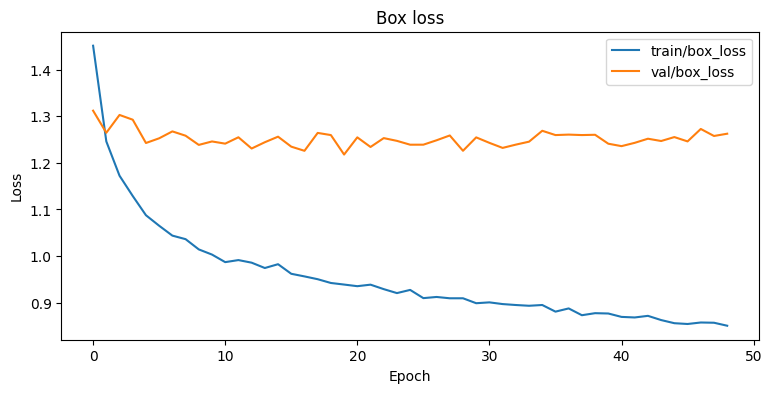

In [21]:
assert RESULTS_CSV.is_file(), RESULTS_CSV

history = pd.read_csv(RESULTS_CSV)
history.columns = history.columns.str.strip()

loss_columns = [
    column
    for column in ("train/box_loss", "val/box_loss")
    if column in history.columns
]

history[loss_columns].plot(
    figsize=(9, 4),
    xlabel="Epoch",
    ylabel="Loss",
    title="Box loss",
)
plt.show()


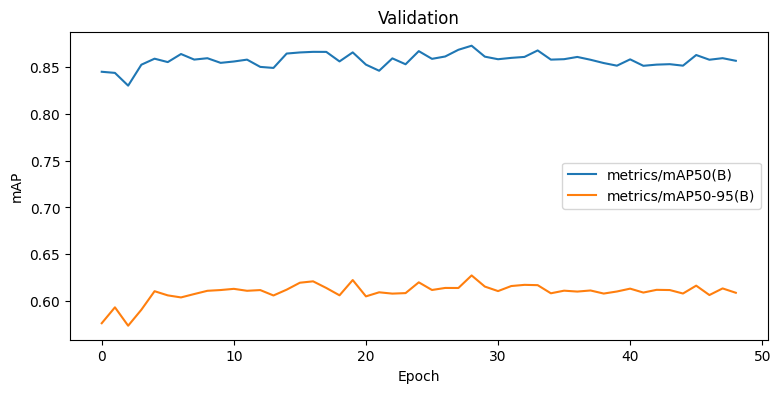

Última epoch registrada: 49
Melhor epoch pela métrica principal: 29


In [22]:
map_columns = [
    column
    for column in history.columns
    if column.startswith("metrics/mAP")
]

history[map_columns].plot(
    figsize=(9, 4),
    xlabel="Epoch",
    ylabel="mAP",
    title="Validation",
)
plt.show()

map_main = next(column for column in map_columns if "95" in column)
best_index = history[map_main].idxmax()

print("Última epoch registrada:", int(history.tail(1).iloc[0]["epoch"]))
print("Melhor epoch pela métrica principal:", int(history.loc[best_index, "epoch"]))


## 16. Carregar o melhor *checkpoint*

Para avaliar e fazer inferência, usamos `best.pt`. O estado mais recente nem sempre é o que apresenta o melhor comportamento fora do conjunto de treino.


In [23]:
assert BEST_CHECKPOINT.is_file(), BEST_CHECKPOINT

best_model = YOLO(str(BEST_CHECKPOINT))

print("Checkpoint final:", BEST_CHECKPOINT)


Checkpoint final: /content/drive/MyDrive/thermal-sar-pop-detection/experiments/yolov8s_pop_sar_live/weights/best.pt


## 17. Fazer uma verificação agregada

Uma avaliação em todo o conjunto de teste confirma que o resultado não depende apenas das imagens escolhidas para demonstração.


In [24]:
test_metrics = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=IMGSZ,
    batch=BATCH,
    conf=0.001,
    device=0,
    plots=False,
    verbose=False,
)

pd.DataFrame([{
    "mAP50": float(test_metrics.box.map50),
    "mAP50_95": float(test_metrics.box.map),
}])


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1938.0±589.9 MB/s, size: 87.0 KB)
val: Scanning /content/pop_work/pop_yolo/labels/test... 900 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 900/900 1.6Kit/s 0.6s
val: New cache created: /content/pop_work/pop_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R


      mAP50  mAP50_95
0  0.807732  0.436733


## 18. Inspeção visual

Comparamos um detector generalista com o YOLOv8s adaptado ao POP nas mesmas cenas de teste. Usamos três poses: em pé, em deslocamento e deitada.

O peso adaptado é o `best.pt` produzido acima. Se você pulou o treinamento, aponte `BEST_CHECKPOINT` para um arquivo que você já tenha gerado.


In [25]:
INFER_NAMES = [
    "T1_0000_30.291.JPG",
    "T1_0198_30.452.JPG",
    "T1_0082_29.847.JPG",
]

TEST_IMAGES = POP_ROOT / "test/JPEGImages"
images_by_name = {item["file_name"]: item for item in test_coco["images"]}
ann_by_image_id = {}
for annotation in test_coco["annotations"]:
    ann_by_image_id.setdefault(annotation["image_id"], []).append(annotation)

for name in INFER_NAMES:
    assert name in images_by_name, name
    assert (TEST_IMAGES / name).is_file(), name

CONF = 0.25
NMS_IOU = 0.70

generalista = YOLO("yolo11s.pt")
adaptado = best_model


def gt_xyxy(image_name):
    image = images_by_name[image_name]
    boxes_gt = []
    for annotation in ann_by_image_id.get(image["id"], []):
        x, y, width, height = annotation["bbox"]
        boxes_gt.append([x, y, x + width, y + height])
    if not boxes_gt:
        return torch.zeros((0, 4))
    return torch.tensor(boxes_gt, dtype=torch.float32)


def result_to_tensor(pred):
    if pred.boxes is None or len(pred.boxes) == 0:
        return (
            torch.zeros((0, 4)),
            torch.zeros((0,)),
            torch.zeros((0,), dtype=torch.long),
            [],
        )
    xyxy = pred.boxes.xyxy.detach().cpu().float()
    conf = pred.boxes.conf.detach().cpu().float()
    cls = pred.boxes.cls.detach().cpu().long()
    names = [pred.names[int(item)] for item in cls]
    return xyxy, conf, cls, names


def apply_filters(xyxy, conf, cls, names, conf_thr=CONF, iou_thr=NMS_IOU):
    if len(conf) == 0:
        return xyxy, conf, cls, names
    keep = conf >= conf_thr
    xyxy, conf, cls = xyxy[keep], conf[keep], cls[keep]
    names = [name for name, flag in zip(names, keep.tolist()) if flag]
    if len(conf) == 0:
        return xyxy, conf, cls, names
    order = nms(xyxy, conf, iou_thr)
    names = [names[int(i)] for i in order.tolist()]
    return xyxy[order], conf[order], cls[order], names


def prever(model, names):
    results = model.predict(
        source=[str(TEST_IMAGES / name) for name in names],
        imgsz=IMGSZ,
        conf=CONF,
        iou=NMS_IOU,
        verbose=False,
    )
    packed = {}
    for name, pred in zip(names, results):
        xyxy, conf, cls, labels = result_to_tensor(pred)
        packed[name] = apply_filters(xyxy, conf, cls, labels)
    return packed


print("Inferindo as cenas de demonstração.")
pred_generalista = prever(generalista, INFER_NAMES)
pred_adaptado = prever(adaptado, INFER_NAMES)
print("Pronto.")
INFER_NAMES


Inferindo as cenas de demonstração.
Pronto.


['T1_0000_30.291.JPG', 'T1_0198_30.452.JPG', 'T1_0082_29.847.JPG']


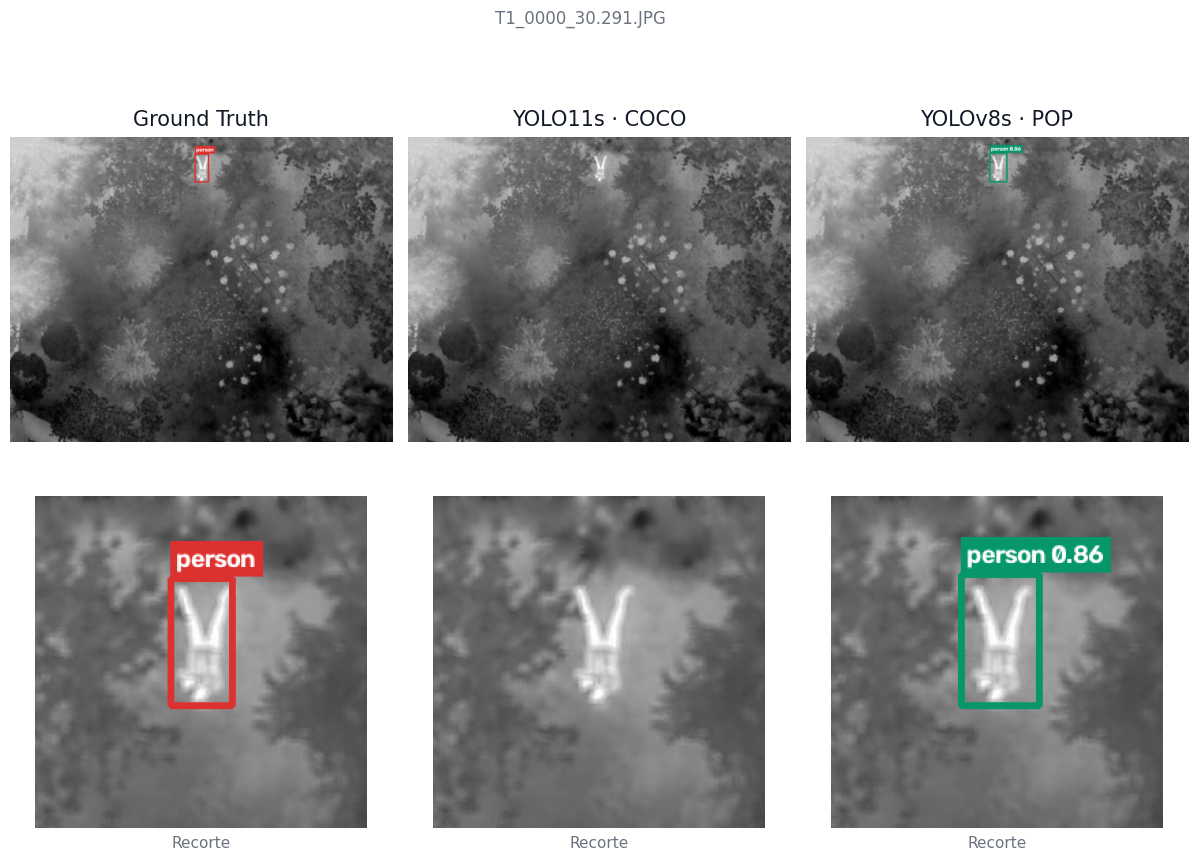

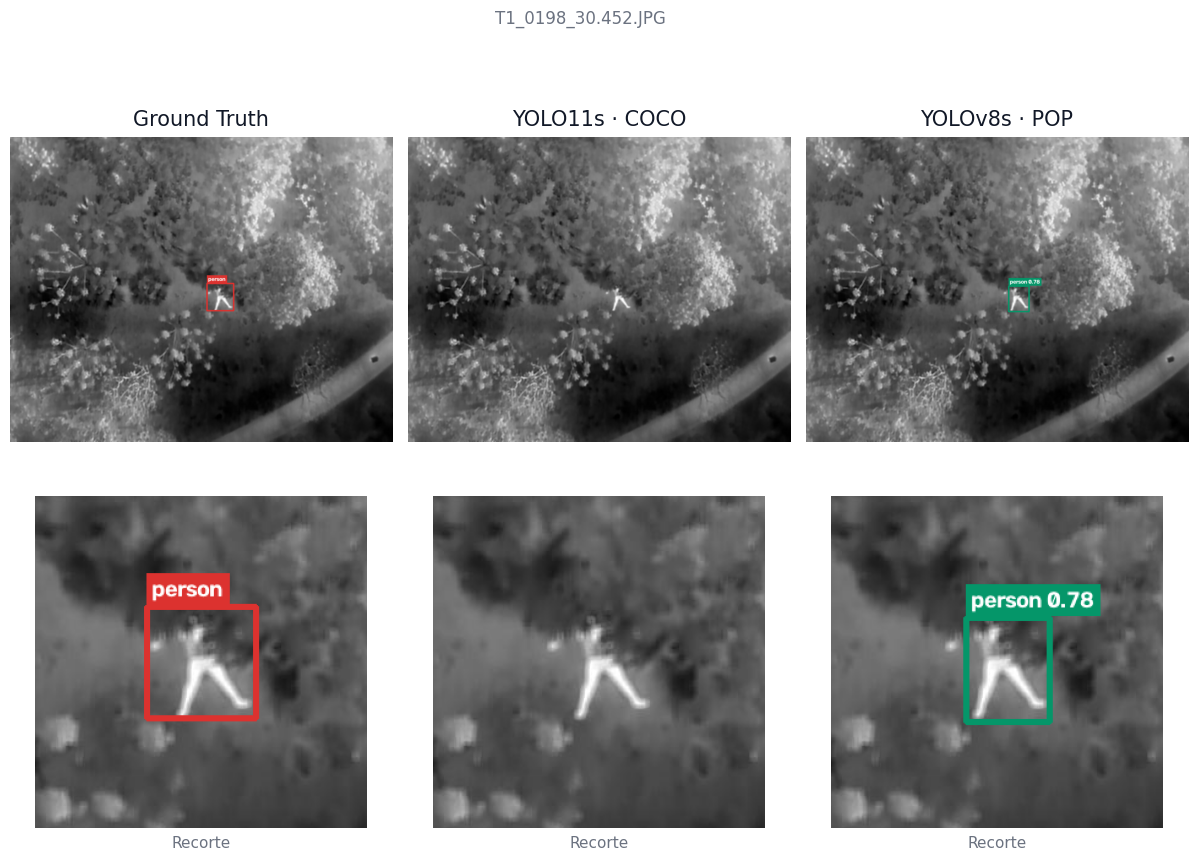

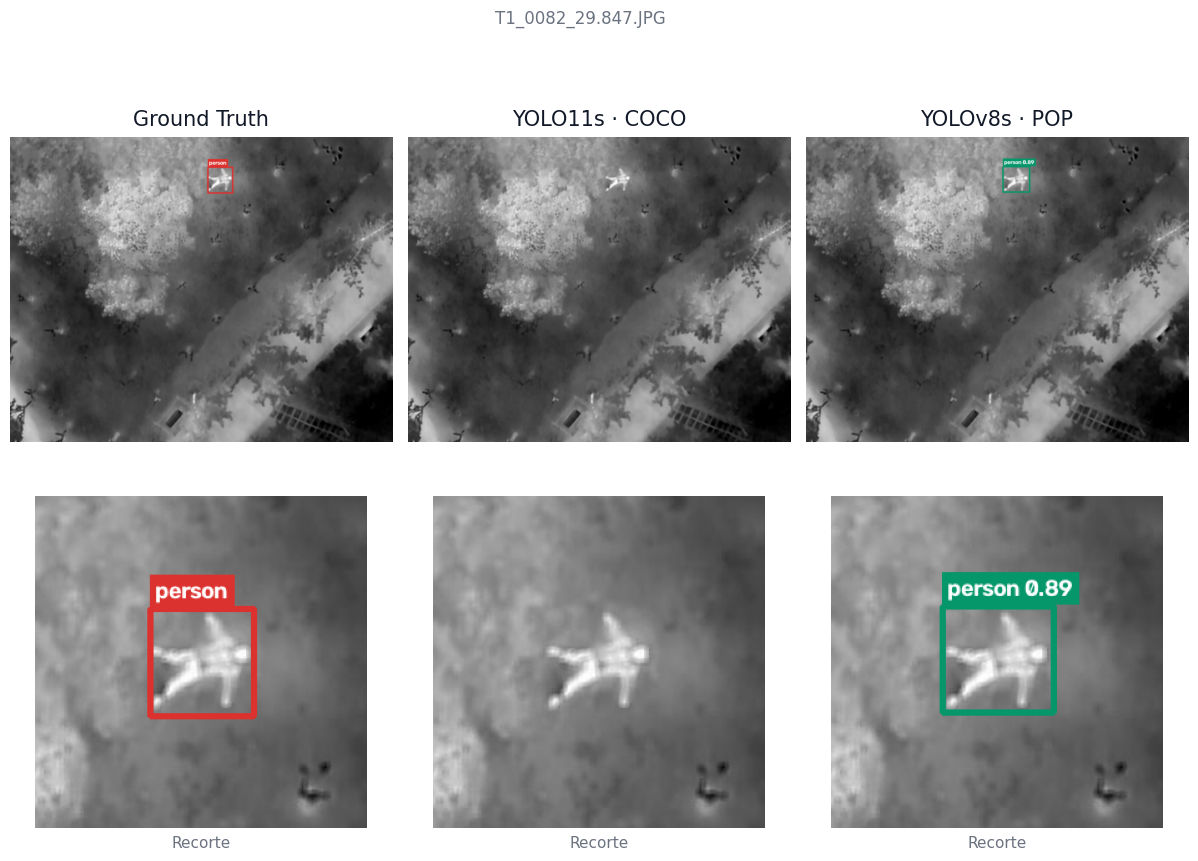

In [26]:
GT_COR = (220, 50, 47)
GEN_COR = (37, 99, 235)
POP_COR = (5, 150, 105)


def carregar(name):
    image = cv2.imread(str(TEST_IMAGES / name))
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def desenhar(image, xyxy, labels=None, scores=None, cor=GT_COR, escrever=True):
    canvas = image.copy()
    for i, box in enumerate(xyxy):
        x1, y1, x2, y2 = [int(round(float(v))) for v in box]
        cv2.rectangle(canvas, (x1, y1), (x2, y2), cor, 3)
        if not escrever:
            continue
        if labels is None:
            texto = "person"
        else:
            score = "" if scores is None else f" {float(scores[i]):.2f}"
            texto = f"{labels[i]}{score}"
        (tw, th), _ = cv2.getTextSize(texto, cv2.FONT_HERSHEY_SIMPLEX, 0.62, 2)
        y0 = max(0, y1 - th - 10)
        cv2.rectangle(canvas, (x1, y0), (x1 + tw + 8, y0 + th + 8), cor, -1)
        cv2.putText(
            canvas,
            texto,
            (x1 + 4, y0 + th + 2),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.62,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )
    return canvas


def recorte(image, boxes_in, pad=90):
    if len(boxes_in) == 0:
        return image
    h, w = image.shape[:2]
    x1 = max(0, int(boxes_in[:, 0].min()) - pad)
    y1 = max(0, int(boxes_in[:, 1].min()) - pad)
    x2 = min(w, int(boxes_in[:, 2].max()) + pad)
    y2 = min(h, int(boxes_in[:, 3].max()) + pad)
    lado = max(x2 - x1, y2 - y1)
    cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
    x1 = max(0, cx - lado // 2)
    y1 = max(0, cy - lado // 2)
    x2 = min(w, x1 + lado)
    y2 = min(h, y1 + lado)
    return image[y1:y2, x1:x2]


def montar_cena(name):
    rgb = carregar(name)
    gt = gt_xyxy(name)
    gen_xyxy, gen_conf, _, gen_names = pred_generalista[name]
    pop_xyxy, pop_conf, _, pop_names = pred_adaptado[name]

    gt_full = desenhar(rgb, gt, cor=GT_COR)
    gen_full = desenhar(rgb, gen_xyxy, gen_names, gen_conf, cor=GEN_COR)
    pop_full = desenhar(rgb, pop_xyxy, pop_names, pop_conf, cor=POP_COR)

    fig = plt.figure(figsize=(15.2, 9.4), facecolor="white")
    gs = fig.add_gridspec(2, 3, height_ratios=[1.12, 1], hspace=0.06, wspace=0.04)
    paineis = [
        (gt_full, "Ground Truth"),
        (gen_full, "YOLO11s · COCO"),
        (pop_full, "YOLOv8s · POP"),
        (recorte(gt_full, gt), "Recorte"),
        (recorte(gen_full, gt), "Recorte"),
        (recorte(pop_full, gt), "Recorte"),
    ]
    for i, (img, titulo) in enumerate(paineis):
        axis = fig.add_subplot(gs[i // 3, i % 3])
        axis.imshow(img)
        axis.set_xticks([])
        axis.set_yticks([])
        for spine in axis.spines.values():
            spine.set_visible(False)
        if i < 3:
            axis.set_title(titulo, fontsize=15, pad=8, color="#111827")
        else:
            axis.set_xlabel(titulo, fontsize=11, labelpad=6, color="#6B7280")
    fig.suptitle(name, fontsize=12, color="#6B7280", y=0.98)
    plt.show()
    plt.close(fig)


for name in INFER_NAMES:
    montar_cena(name)


## 19. Isolar o efeito dos pesos

Repetimos uma cena com YOLOv8s treinado no COCO e com YOLOv8s adaptado ao POP. A família de arquitetura é a mesma. O que muda é a experiência visual registrada nos pesos.


YOLOv8s COCO: [('broccoli', 0.33)]
YOLOv8s POP:  [('person', 0.86)]


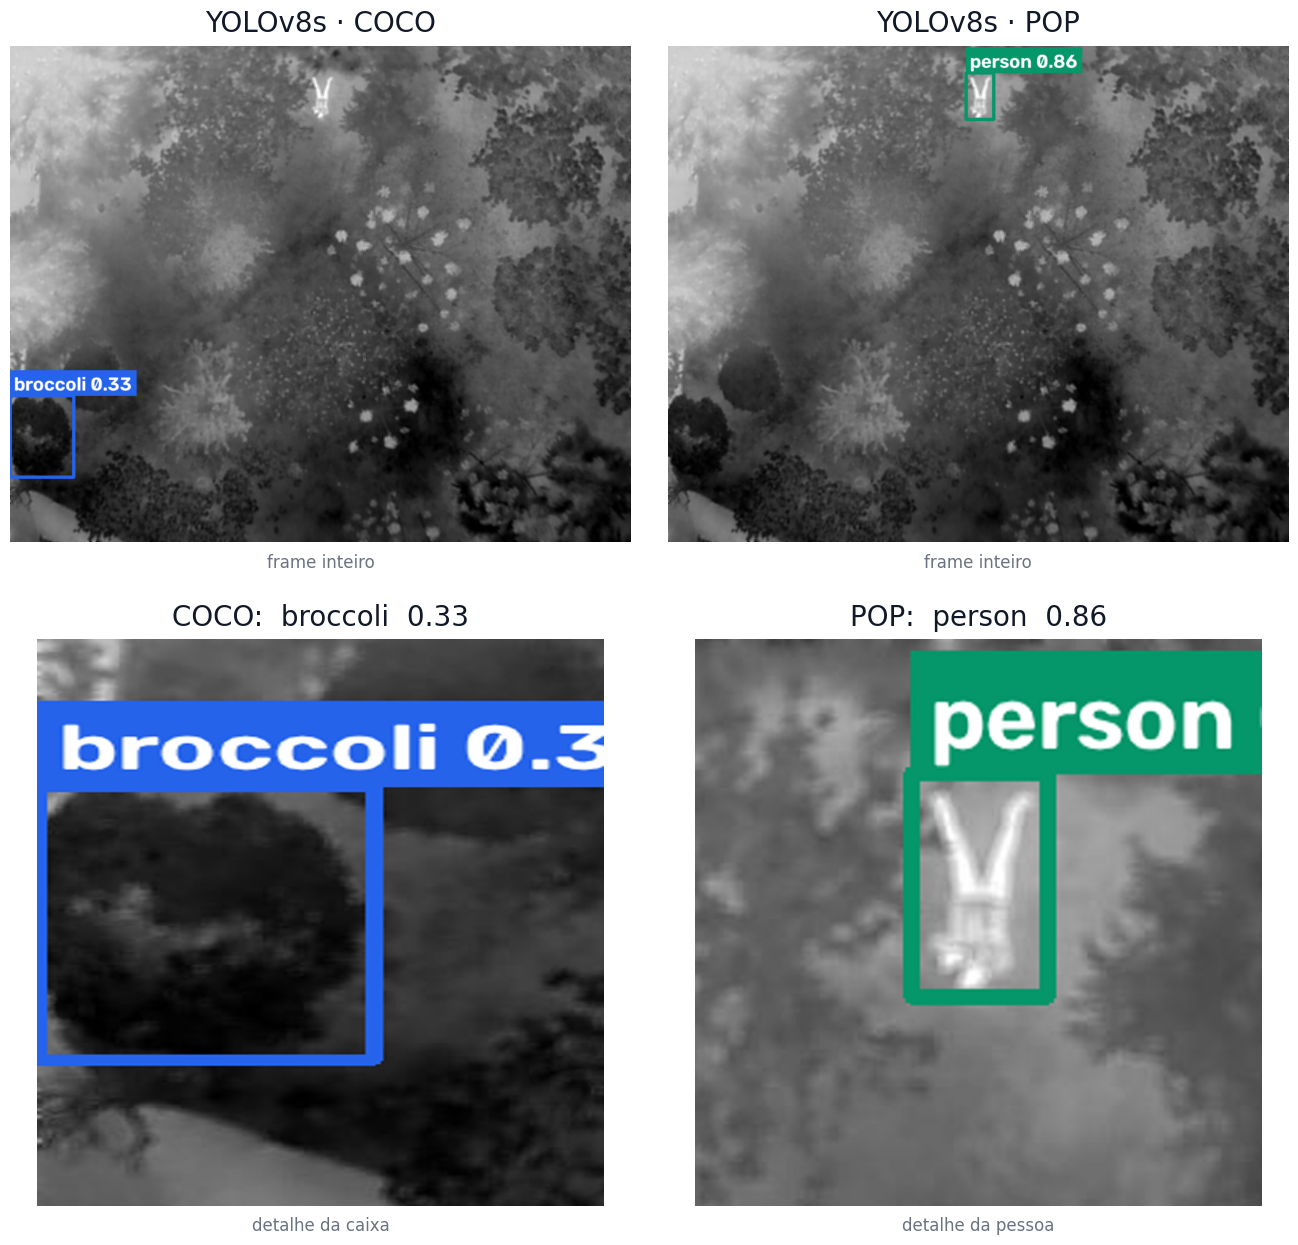

In [27]:
CENA = INFER_NAMES[0]

coco_v8 = YOLO("yolov8s.pt")
pred_v8 = prever(coco_v8, [CENA])

rgb = carregar(CENA)
gt = gt_xyxy(CENA)
v8_xyxy, v8_conf, _, v8_names = pred_v8[CENA]
pop_xyxy, pop_conf, _, pop_names = pred_adaptado[CENA]

print("YOLOv8s COCO:", list(zip(v8_names, [round(float(s), 2) for s in v8_conf])))
print("YOLOv8s POP: ", list(zip(pop_names, [round(float(s), 2) for s in pop_conf])))


def desenhar_grosso(image, xyxy, labels=None, scores=None, cor=GT_COR):
    canvas = image.copy()
    for i, box in enumerate(xyxy):
        x1, y1, x2, y2 = [int(round(float(v))) for v in box]
        cv2.rectangle(canvas, (x1, y1), (x2, y2), cor, 6)
        if labels is None:
            texto = "person"
        else:
            score = "" if scores is None else f" {float(scores[i]):.2f}"
            texto = f"{labels[i]}{score}"
        fonte = cv2.FONT_HERSHEY_SIMPLEX
        escala, grossura = 1.35, 3
        (tw, th), _ = cv2.getTextSize(texto, fonte, escala, grossura)
        y0 = max(0, y1 - th - 16)
        x0 = max(0, x1)
        cv2.rectangle(canvas, (x0, y0), (x0 + tw + 16, y0 + th + 16), cor, -1)
        cv2.putText(
            canvas,
            texto,
            (x0 + 8, y0 + th + 6),
            fonte,
            escala,
            (255, 255, 255),
            grossura,
            cv2.LINE_AA,
        )
    return canvas


def zoom_caixa(image, box, pad=90, lado=800):
    h, w = image.shape[:2]
    x1, y1, x2, y2 = [int(round(float(v))) for v in box]
    x1, y1 = max(0, x1 - pad), max(0, y1 - pad)
    x2, y2 = min(w, x2 + pad), min(h, y2 + pad)
    recorte_img = image[y1:y2, x1:x2]
    return cv2.resize(recorte_img, (lado, lado), interpolation=cv2.INTER_CUBIC)


coco_full = desenhar_grosso(rgb, v8_xyxy, v8_names, v8_conf, cor=GEN_COR)
pop_full = desenhar_grosso(rgb, pop_xyxy, pop_names, pop_conf, cor=POP_COR)

if len(v8_xyxy):
    i_v8 = int(v8_conf.argmax())
    coco_zoom = zoom_caixa(coco_full, v8_xyxy[i_v8])
    coco_legenda = f"{v8_names[i_v8]}  {float(v8_conf[i_v8]):.2f}"
else:
    coco_zoom = zoom_caixa(coco_full, gt[0])
    coco_legenda = "nenhuma detecção"

if len(pop_xyxy):
    i_pop = int(pop_conf.argmax())
    pop_zoom = zoom_caixa(pop_full, pop_xyxy[i_pop])
    pop_legenda = f"{pop_names[i_pop]}  {float(pop_conf[i_pop]):.2f}"
else:
    pop_zoom = zoom_caixa(pop_full, gt[0])
    pop_legenda = "nenhuma detecção"

fig = plt.figure(figsize=(16.5, 15.2), facecolor="white")
gs = fig.add_gridspec(2, 2, height_ratios=[1.05, 1.15], hspace=0.16, wspace=0.06)
paineis = [
    (coco_full, "YOLOv8s · COCO", "frame inteiro"),
    (pop_full, "YOLOv8s · POP", "frame inteiro"),
    (coco_zoom, f"COCO:  {coco_legenda}", "detalhe da caixa"),
    (pop_zoom, f"POP:  {pop_legenda}", "detalhe da pessoa"),
]
for i, (img, titulo, sub) in enumerate(paineis):
    axis = fig.add_subplot(gs[i // 2, i % 2])
    axis.imshow(img)
    axis.set_xticks([])
    axis.set_yticks([])
    for spine in axis.spines.values():
        spine.set_visible(False)
    axis.set_title(titulo, fontsize=20, pad=10, color="#111827")
    axis.set_xlabel(sub, fontsize=12, labelpad=8, color="#6B7280")
plt.show()
plt.close(fig)


## 20. Leitura dos resultados

Nestas cenas, o modelo generalista não associa o padrão térmico aéreo à classe `person`. O modelo adaptado localiza a pessoa nas três poses observadas.

Isso não prova que YOLOv8s seja a melhor arquitetura para qualquer missão. Mostra que a aparência do alvo muda com o sensor, a perspectiva, a escala e a pose, e que dados representativos alteram o comportamento do detector.

Uma avaliação completa combina medidas agregadas, inspeção visual e análise dos casos de falha. O próximo passo natural, quando um único canal deixa evidência incompleta, é combinar o ramo térmico com imagens ópticas da mesma cena.
